# **1. Introduction: The Case for Cross‑Learning**
- __Act 2:__ The Strategic Approach (Global Scaling).  
- **Goal:** engineer a pipeline that handles ~30k series on a single machine.  
- **Cross‑learning:** a single model learns shared seasonal and event effects across **all series**. 

## Evaluation Contract (Act 2 — Global Scale)
- **Task:** 28‑day ahead daily forecasting across **all item‑store series** (≈30k series).
- **Resource constraint:** full M5 is ~59M rows; this notebook uses **dtype downcasting** and optionally truncates history before `START_DAY` to fit a single machine.
- **Split:** single contiguous time split — train on history, hold out the **final 28 days** for test (and use the preceding 28 days for validation where applicable).
- **Reporting metrics:**
  - **RMSE** computed on point forecasts (LightGBM) or the **median** forecast (N‑BEATSx trained with MQLoss).
  - **WRMSSE (item‑level only / Level 12)** for business‑weighted accuracy; full 12‑level WRMSSE is intentionally out of scope for laptop RAM/time.
- **Interpretation rule:** improvements are reported for this evaluation protocol; alternative splits or full hierarchical scoring may change the ranking.

# **2. RAM‑Optimized Data Pipeline**
- Import the custom loader: `from src.data_loader import load_global_m5`.  
- Downcast (`float32`, `int16`) and cut history before `START_DAY` to fit RAM constraints.

In [ ]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import gc
import os
# from sklearn.preprocessing import OrdinalEncoder

# Allow importing from the project root (../src) when running from Notebooks/
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.m5.split import contiguous_day_split, split_date_for_last_horizon, train_test_split_by_date
from src.m5.eval import rmse, merge_on_id_date
from src.m5.metrics import compute_item_level_wrmsse
from src.m5.lgbm_tuning import tune_lightgbm_optuna
from src.m5.lgbm_training import train_lightgbm_with_best_params
from src.m5.lgbm_io import save_lgbm_model, load_lgbm_model
from src.m5.lgbm_inference import evaluate_lgbm_on_test_mask
from src.m5.neuralforecast_utils import (
    fit_neuralforecast,
    load_neuralforecast,
    make_csv_logger,
    make_nbtx_mql_model,
    make_neuralforecast,
    merge_forecasts_with_actuals,
    predict_neuralforecast,
    reset_logs_dir,
    rmse_on_column,
    save_neuralforecast,
 )
from src.m5.nf_plotting import plot_nf_learning_curves
from src.utils.m5_features import add_snap_active, add_cyclical_time_features, add_group_lags, add_group_rolling_means

**Constraint:** full M5 ≈ 59M rows.  
**Strategy:** downcast dtypes + limit history to `START_DAY` while keeping a lag buffer.  
**Trade‑off:** less long‑term history, faster training.

In [ ]:
# Utility imported above: `from src.utils.memory import read_and_squeeze`
# (kept in `src/utils/memory.py` so it can be unit-tested and reused).

# **3. Model B: Global LightGBM (The Control)**
- **Control model:** LightGBM with manual feature engineering (lags/rolling stats + calendar + price + SNAP + events).
- **Purpose:** establishes a strong non‑DL baseline on the **same global time window**.
- **Fairness note:** this baseline intentionally benefits from **hand‑crafted features** and richer calendar/event fields. The N‑BEATSx pipeline uses a **smaller curated exogenous set** (price/availability/SNAP/event flag) and learns the rest. The comparison is therefore about **accuracy + engineering burden**, not just raw modeling power.
- **Result (this split):** Global RMSE (~2.1889).

### Loading and preprocessing data

In [2]:
import pandas as pd
import numpy as np
import os
import torch
import lightgbm as lgb
import gc

from src.m5.loader import load_global_lgbm

# ==========================================
# 1. CONFIGURATION (RAM OPTIMIZED)
# ==========================================
TARGET = 'sales'
HORIZON = 28
# We need a buffer to calculate lags.
# If we want to train from Day 1200, we need Day 1140 loaded to calc lag_60.
START_DAY = 1200
BUFFER = 60

print("Loading Global M5 Dataset for LightGBM...")

# ==========================================
# 2. DATA LOADING (The RAM Safe Way)
# ==========================================
df_lgbm_glob = load_global_lgbm(start_day=START_DAY, buffer=BUFFER)

Loading Global M5 Dataset for LightGBM...
For sales_train_evaluation.csv, mem. usage decreased from 452.91 Mb to 96.13 Mb (78.8% reduction)
For calendar.csv, mem. usage decreased from  0.21 Mb to  0.12 Mb (41.9% reduction)
For sell_prices.csv, mem. usage decreased from 208.77 Mb to 130.48 Mb (37.5% reduction)


### Feature engeneering

In [3]:
# ==========================================
# 3. FEATURE ENGINEERING
# ==========================================
print("Engineering Features...")

# 1. Cyclical time features (moved to src/utils/m5_features.py)
add_cyclical_time_features(df_lgbm_glob, wday_col="wday", month_col="month")

# 2. Fill NaNs in Event Columns (Crucial for M5)
event_cols = ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']
for col in event_cols:
    df_lgbm_glob[col] = df_lgbm_glob[col].astype('object').fillna("NoEvent")

# 4. Dynamic SNAP (moved to src/utils/m5_features.py)
add_snap_active(df_lgbm_glob, state_col="state_id")

# 3. Encode Categoricals
cat_feats = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'snap_active'] + event_cols
for col in cat_feats:
    df_lgbm_glob[col] = df_lgbm_glob[col].astype('category')

# 5. Lags & Rolling (moved to src/utils/m5_features.py)
print("Creating Lags...")
lags = [28, 35, 42, 49]
df_lgbm_glob, lag_cols = add_group_lags(
    df_lgbm_glob, group_col="id", value_col="sales", lags=lags, dtype="float32"
 )

print("Creating Rolling Means...")
df_lgbm_glob, rolling_cols = add_group_rolling_means(
    df_lgbm_glob,
    group_col="id",
    value_col="sales",
    shift=28,
    windows=[7, 28, 49],
    dtype="float32",
)

# ==========================================
# 4. TRAINING PREP
# ==========================================
# Now we cut off the buffer. We only wanted it to calculate the lags.
df_lgbm_glob = df_lgbm_glob[df_lgbm_glob['d_int'] >= START_DAY]

# Drop NaNs created by lags/rolling warmup
df_lgbm_glob = df_lgbm_glob.dropna(subset=lag_cols + rolling_cols)

# Split (refactored)
split = contiguous_day_split(df_lgbm_glob, horizon=HORIZON, d_int_col="d_int")
max_d = split.max_d
test_start_d = split.test_start
valid_start_d = split.valid_start
train_mask = split.train_mask
valid_mask = split.valid_mask
test_mask = split.test_mask

# Define features (Drop IDs that aren't features)
drop_cols = ['sales', 'd', 'date', 'wm_yr_wk', 'month', 'wday', 'snap_CA', 'snap_TX', 'snap_WI']
features = [c for c in df_lgbm_glob.columns if c not in drop_cols]

print(f"Training on {train_mask.sum()} rows. \nValidating on {valid_mask.sum()} rows. \nTesting on {test_mask.sum()} rows. \n")

# convert 'date' column to datetime
df_lgbm_glob['date'] = pd.to_datetime(df_lgbm_glob['date']) 

# sanity check
# print the min and max dates in df_lgbm_glob[train_mask] and df_lgbm_glob[valid_mask] and df_lgbm_glob[test_mask]
print(f"Train Set Timeframe: {df_lgbm_glob[train_mask]['date'].min().date()} to {df_lgbm_glob[train_mask]['date'].max().date()}")
print(f"Valid Set Timeframe: {df_lgbm_glob[valid_mask]['date'].min().date()} to {df_lgbm_glob[valid_mask]['date'].max().date()}")
print(f"Test Set Timeframe: {df_lgbm_glob[test_mask]['date'].min().date()} to {df_lgbm_glob[test_mask]['date'].max().date()}")

# Create LGB Datasets
train_data = lgb.Dataset(
    df_lgbm_glob[train_mask][features],
    label=df_lgbm_glob[train_mask]['sales'],
    categorical_feature=cat_feats,
    free_raw_data=True
)
valid_data = lgb.Dataset(
    df_lgbm_glob[valid_mask][features],
    label=df_lgbm_glob[valid_mask]['sales'],
    reference=train_data,
    free_raw_data=True
)

Engineering Features...
Creating Lags...
Creating Rolling Means...
Training on 20428300 rows. 
Validating on 853720 rows. 
Testing on 853720 rows. 

Train Set Timeframe: 2014-05-28 to 2016-03-27
Valid Set Timeframe: 2016-03-28 to 2016-04-24
Test Set Timeframe: 2016-04-25 to 2016-05-22


In [4]:
df_lgbm_glob[test_mask][features]

,id,item_id,dept_id,cat_id,store_id,state_id,d_int,year,event_name_1,event_type_1,...,month_sin,month_cos,snap_active,lag_28,lag_35,lag_42,lag_49,rolling_mean_7,rolling_mean_28,rolling_mean_49
23599260,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1914,2016,NoEvent,NoEvent,...,0.866025,-0.500000,0,1.0,1.0,0.0,0.0,1.142857,1.035714,1.061224
23599261,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,1914,2016,NoEvent,NoEvent,...,0.866025,-0.500000,0,1.0,0.0,0.0,1.0,0.714286,0.357143,0.265306
23599262,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,1914,2016,NoEvent,NoEvent,...,0.866025,-0.500000,0,0.0,0.0,0.0,1.0,0.285714,0.535714,0.469388
23599263,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,1914,2016,NoEvent,NoEvent,...,0.866025,-0.500000,0,0.0,4.0,3.0,3.0,3.000000,1.892857,1.877551
23599264,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,1914,2016,NoEvent,NoEvent,...,0.866025,-0.500000,0,1.0,2.0,2.0,2.0,0.714286,1.107143,1.142857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24452975,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,1941,2016,NoEvent,NoEvent,...,0.500000,-0.866025,0,1.0,0.0,0.0,0.0,0.285714,0.214286,0.163265
24452976,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,1941,2016,NoEvent,NoEvent,...,0.500000,-0.866025,0,0.0,0.0,1.0,1.0,0.142857,0.321429,0.183673
24452977,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,1941,2016,NoEvent,NoEvent,...,0.500000,-0.866025,0,0.0,0.0,2.0,1.0,0.571429,0.892857,0.959184
24452978,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,1941,2016,NoEvent,NoEvent,...,0.500000,-0.866025,0,3.0,1.0,2.0,1.0,1.142857,0.928571,1.000000


### Training

In [5]:
import os
import random
import numpy as np

# Reproducibility (keeps the Optuna search + sampling repeatable)
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
# Note: `PYTHONHASHSEED` only fully applies if set before the kernel starts.
os.environ.setdefault("PYTHONHASHSEED", str(SEED))

print("Starting Hyperparameter Tuning with Optuna...")

# 1. Create a smaller dataset for tuning to save time
# (baseline: small subsample so it runs on a laptop)
df_tune = df_lgbm_glob[train_mask].sample(frac=0.1, random_state=SEED)

# 2. Run Optuna + LightGBM CV tuning (refactored helper)
study, tune_data = tune_lightgbm_optuna(
    df_tune,
    features=features,
    y_col="sales",
    cat_feats=cat_feats,
    seed=SEED,
    n_trials=15,
    nfold=3,
    num_boost_round=500,
    free_raw_data=False,
    return_tune_data=True,
 )

print("Best Parameters found:")
print(study.best_params)

Starting Hyperparameter Tuning with Optuna...


[I 2026-01-22 14:42:44,376] A new study created in memory with name: M5_LGBM_Global
[I 2026-01-22 14:44:49,727] Trial 0 finished with value: 2.2649261319853724 and parameters: {'tweedie_variance_power': 1.249816047538945, 'learning_rate': 0.09556428757689246}. Best is trial 0 with value: 2.2649261319853724.
[I 2026-01-22 14:47:06,548] Trial 1 finished with value: 2.2755531638816957 and parameters: {'tweedie_variance_power': 1.3927975767245622, 'learning_rate': 0.0638792635777333}. Best is trial 0 with value: 2.2649261319853724.
[I 2026-01-22 14:49:10,209] Trial 2 finished with value: 2.2885407962891744 and parameters: {'tweedie_variance_power': 1.1624074561769746, 'learning_rate': 0.02403950683025824}. Best is trial 0 with value: 2.2649261319853724.
[I 2026-01-22 14:51:10,837] Trial 3 finished with value: 2.2669520365821794 and parameters: {'tweedie_variance_power': 1.1232334448672798, 'learning_rate': 0.08795585311974417}. Best is trial 0 with value: 2.2649261319853724.
[I 2026-01-22 

Best Parameters found:
{'tweedie_variance_power': 1.1030189277265174, 'learning_rate': 0.09596292009666046}


In [6]:
# ==========================================
# 5. TRAINING (optimized + fast + seeded)
# ==========================================
print("Training Global LightGBM with Optimized Parameters...")

# Keep the same seed used in Optuna
SEED = 42

model, params = train_lightgbm_with_best_params(
    train_data=train_data,
    valid_data=valid_data,
    best_params=study.best_params,
    seed=SEED,
    objective="tweedie",
    metric="rmse",
    bin_construct_sample_cnt=200000,
    num_threads=-1,
    verbose=-1,
    num_boost_round=1500,
    early_stopping_rounds=100,
    log_evaluation=50,
)

Training Global LightGBM with Optimized Parameters...
Training until validation scores don't improve for 100 rounds
[50]	training's rmse: 2.28611	valid_1's rmse: 2.17094
[100]	training's rmse: 2.23469	valid_1's rmse: 2.15482
[150]	training's rmse: 2.20855	valid_1's rmse: 2.15056
[200]	training's rmse: 2.18266	valid_1's rmse: 2.14899
[250]	training's rmse: 2.16114	valid_1's rmse: 2.15033
[300]	training's rmse: 2.13974	valid_1's rmse: 2.1482
[350]	training's rmse: 2.12624	valid_1's rmse: 2.14981
[400]	training's rmse: 2.10516	valid_1's rmse: 2.15364
Early stopping, best iteration is:
[318]	training's rmse: 2.13341	valid_1's rmse: 2.14718


### Results and saving the model

In [7]:
# ==========================================
# 6. RESULTS
# ==========================================
print("Global LightGBM Finished.")
print(f"Best validation RMSE: {model.best_score['valid_1']['rmse']:.4f}")

# Save Model
model_path = save_lgbm_model(model, "models/LightGBM/lgbm_global_model.txt")
print(f"Saved LightGBM model to: {model_path}")

Global LightGBM Finished.
Best validation RMSE: 2.1472
Saved LightGBM model to: models/LightGBM/lgbm_global_model.txt


In [4]:
loaded_model = load_lgbm_model("models/LightGBM/lgbm_global_model.txt")

df_lgbm_glob_preds, lgbm_rmse_full = evaluate_lgbm_on_test_mask(
    model=loaded_model,
    df=df_lgbm_glob,
    test_mask=test_mask,
    features=features,
    id_col="id",
    date_col="date",
    y_col="sales",
    d_col="d",
)

print("="*40)
print(f"TEST DATASET Global LightGBM RMSE: {lgbm_rmse_full:.4f}")
print("="*40)

TEST DATASET Global LightGBM RMSE: 2.2209


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

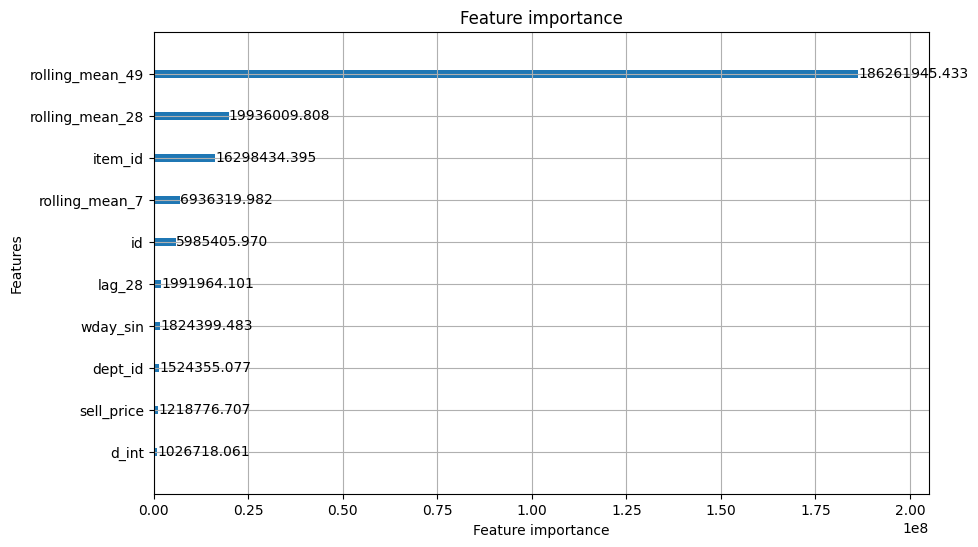

In [5]:
lgb.plot_importance(loaded_model, max_num_features=10, importance_type='gain', figsize=(10, 6))

# **3. Model A: Global N‑BEATSx (The Challenger)**
- Setup the Global Model (batch size 512).  
- **Loss choice:** MQLoss handles heavy‑tailed retail demand; evaluate the **median** for RMSE comparability.  
- **Result:** Global RMSE (~2.1814).

In [6]:
# ==========================================
# 1. CONFIGURATION (RAM OPTIMIZED)
# ==========================================
HORIZON = 28
# We only train on recent history to keep this laptop-scale.
START_DAY = 1200

print("Loading Full M5 Dataset (Optimized for Laptop RAM)...")

# ==========================================
# 2. DATA LOADING (REFactored)
# ==========================================
# Keep full history for metrics like WRMSSE; we filter for training later.
from src.m5.loader import load_global_nf

m5_df = load_global_nf(start_day=None)  # includes d_int + state_id + snap_*
add_snap_active(m5_df, state_col="state_id")

# Keep only what the global N-BEATSx needs (and what we’ll use later)
Y_df = m5_df[['unique_id', 'ds', 'y', 'sell_price', 'is_available', 'snap_active', 'is_event', 'd_int']].copy()

print(f"Full Dataset Shape: {Y_df.shape}")
print(f"Memory Usage: {Y_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Loading Full M5 Dataset (Optimized for Laptop RAM)...
For calendar.csv, mem. usage decreased from  0.21 Mb to  0.12 Mb (41.9% reduction)
For sales_train_evaluation.csv, mem. usage decreased from 452.91 Mb to 96.13 Mb (78.8% reduction)
For sell_prices.csv, mem. usage decreased from 208.77 Mb to 130.48 Mb (37.5% reduction)
Full Dataset Shape: (59181090, 8)
Memory Usage: 6.55 GB


In [7]:
# ==========================================
# 3. SPLIT (Single contiguous holdout)
# ==========================================
split_date = split_date_for_last_horizon(Y_df, horizon=HORIZON, d_int_col='d_int', ds_col='ds')

# ---
print(f"Filtering history < Day {START_DAY}...")
Y_trainable = Y_df[Y_df['d_int'] >= START_DAY].drop(columns=['d_int'])
# ---

train_df, test_df = train_test_split_by_date(Y_trainable, split_date=split_date, ds_col='ds')

# Future exogenous variables for prediction
futr_exog_df = test_df[['unique_id', 'ds', 'sell_price', 'is_available', 'snap_active', 'is_event']]

print(f"Train rows: {len(train_df):,}")
print(f"Test rows:  {len(test_df):,}")

Filtering history < Day 1200...
Train rows: 21,769,860
Test rows:  853,720


In [8]:
# Sanity Check
# Print the max and min dates of train and test sets
print(f"Train Set Timeframe: {train_df['ds'].min().date()} to {train_df['ds'].max().date()}")
print(f"Test Set Timeframe: {test_df['ds'].min().date()} to {test_df['ds'].max().date()}")

# print min and max dates in m5_df
print(f"M5 Full Set Timeframe: {m5_df['ds'].min().date()} to {m5_df['ds'].max().date()}")

Train Set Timeframe: 2014-05-12 to 2016-04-24
Test Set Timeframe: 2016-04-25 to 2016-05-22
M5 Full Set Timeframe: 2011-01-29 to 2016-05-22


**Why MQLoss:**  
Retail demand is heavy‑tailed and zero‑inflated. The **median** is used for RMSE and WRMSSE.

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# ==========================================
# 5 MODEL DEFINITION (FULL DATASET MODE)
# ==========================================
print("Setting up Global N-BEATSx...")

# 1. CLEANUP OLD LOGS (Crucial for reproducible plotting)
reset_logs_dir("logs/nbeats_mqloss_global")

logger_MQLoss_global = make_csv_logger("logs", name="nbeats_mqloss_global")

common_params = dict(
    h=HORIZON,
    input_size=370,
    scaler_type='robust',
    max_steps=8000,          # Give it more time
    val_check_steps=100,     # Check less frequently to speed up
    early_stop_patience_steps=15,
    dropout_prob_theta=0.2,  # Slight increase to force robust features
    futr_exog_list=['sell_price', 'is_available', 'snap_active', 'is_event'],
    exclude_insample_y=False,
    accelerator='mps',
    devices=1,
    batch_size=512,         # <--- Increased for gradient stability
    enable_progress_bar=False,
 )

model_mqloss_global = make_nbtx_mql_model(
    common_params,
    learning_rate=5e-4,      # <--- Lowered from 1e-3 (Slower but safer)
    quantiles=(0.5, 0.8, 0.9),
    alias='NBEATSx_MQLoss_Stable',
    logger=logger_MQLoss_global,
    lr_scheduler=CosineAnnealingWarmRestarts,
    lr_scheduler_kwargs={
        'T_0': 2000,         # <--- Restart later (let it settle)
        'T_mult': 4,         # <--- Double the cycle length each time
        'eta_min': 1e-6,
    },
 )

nf_mqloss_global = make_neuralforecast(models=[model_mqloss_global], freq='D')

Setting up Global N-BEATSx...


Seed set to 1


In [ ]:
# ==========================================
# SINGLE SPLIT TRAINING
# ==========================================
# Note on the runtime: On a MacBook Pro M1 Pro, this takes approx 26 minutes to train.

print("Starting Global Training...")

# val_size=28 triggers the internal validation loop using the last 28 days of train_df
fit_neuralforecast(nf=nf_mqloss_global, df=train_df, val_size=28)

print("Global Training Complete.")

Starting Global Training...


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MQLoss        | 3      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 5.8 M  | train
-------------------------------------------------------
5.7 M     Trainable params
22.7 K    Non-trainable params
5.8 M     Total params
23.007    Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode
`Trainer.fit` stopped: `max_steps=8000` reached.


Global Training Complete.


In [ ]:
# ==========================================
# 7. SAVE MODEL
# ==========================================
print("Saving Model to Disk...")

# This creates a folder named 'nbeatsx_m5_global'
save_neuralforecast(nf=nf_mqloss_global, path='models/NBEATSx', overwrite=True, save_dataset=True)

print("Model saved successfully to 'models/NBEATSx'")

Saving Model to Disk...
Model saved successfully to 'models/NBEATSx'


In [ ]:
# Load the model back
print("Loading Model...")
nf_global_loaded = load_neuralforecast(path='models/NBEATSx')

print("Model Loaded. Ready for inference.")

# Example usage:
forecasts = predict_neuralforecast(nf=nf_global_loaded, futr_df=futr_exog_df)
results_forecasts = merge_forecasts_with_actuals(
    forecasts=forecasts,
    actuals=test_df[['unique_id', 'ds', 'y']],
    id_col='unique_id',
    ds_col='ds',
    y_col='y',
    how='left',
 )
results_mqloss_stable_full = results_forecasts.copy(deep=True)

display(results_forecasts)

Seed set to 1


Loading Model...
Model Loaded. Ready for inference.


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


,unique_id,ds,NBEATSx_MQLoss_Stable-median,NBEATSx_MQLoss_Stable-hi-60.0,NBEATSx_MQLoss_Stable-hi-80.0,y
0,FOODS_1_001_CA_1_evaluation,2016-04-25,0.004941,1.427917,2.284245,2
1,FOODS_1_001_CA_1_evaluation,2016-04-26,-0.004922,1.395466,2.214075,0
2,FOODS_1_001_CA_1_evaluation,2016-04-27,0.000058,1.399013,2.232355,0
3,FOODS_1_001_CA_1_evaluation,2016-04-28,0.011217,1.426816,2.280685,0
4,FOODS_1_001_CA_1_evaluation,2016-04-29,0.067805,1.554290,2.482586,0
...,...,...,...,...,...,...
853715,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,-0.000055,0.000202,0.032146,0
853716,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,-0.000002,0.000343,0.032764,0
853717,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,-0.000055,0.000275,0.039893,0
853718,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,-0.000120,0.000207,0.043745,0


In [ ]:
print("Calculating RMSE...")
rmse_mqloss_loaded_full = rmse_on_column(
    df=results_forecasts,
    y_col='y',
    pred_col='NBEATSx_MQLoss_Stable-median',
 )

print("="*40)
print(f"FULL DATASET N-BEATSx RMSE: {rmse_mqloss_loaded_full:.4f}")
print("="*40)

Calculating RMSE...
FULL DATASET N-BEATSx RMSE: 2.1814


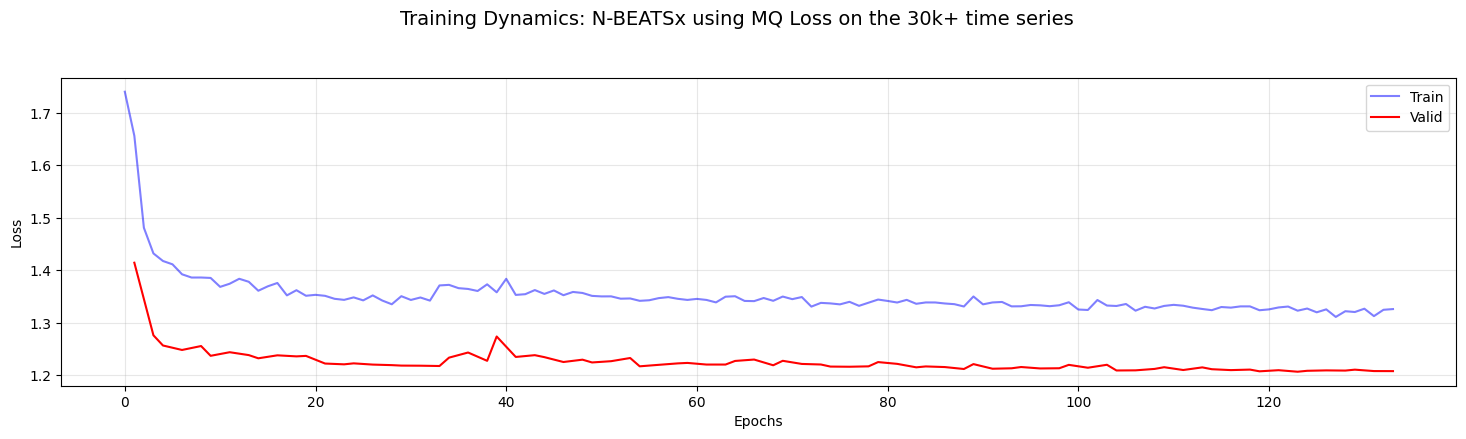

In [ ]:
# Training curves from Lightning CSVLogger
plot_nf_learning_curves(
    model_name="N-BEATSx (MQ Loss) — full dataset",
    log_dir="logs/nbeats_mqloss_global",
    version="0",
    title="Training Dynamics: N-BEATSx using MQ Loss on the 30k+ time series",
 )

# **5. The Results**
- **Evaluation protocol:** single time split; final 28 days held out for testing.  
- **WRMSSE scope:** item‑level only (Level 12). Full 12‑level WRMSSE is not computed due to RAM/time.  
- **Observation:** LightGBM has higher RMSE (2.1889 vs 2.1814) and higher item‑level WRMSSE (0.8669 vs 0.8568).

In [15]:
print("Calculating RMSE for LightGBM and NBEATSx on Full Test Set...")
results_mqloss_lgbm_full = merge_on_id_date(
    results_mqloss_stable_full,
    df_lgbm_glob_preds[['unique_id', 'ds', 'lgbm_pred']],
    id_col='unique_id',
    ds_col='ds',
    how='left',
)

lgbm_rmse_full = rmse(results_mqloss_lgbm_full['y'], results_mqloss_lgbm_full['lgbm_pred'])
mqls_rmse_full = rmse(
    results_mqloss_lgbm_full['y'],
    results_mqloss_lgbm_full['NBEATSx_MQLoss_Stable-median'],
)
print("="*40)
print(f"TEST DATASET Global LightGBM RMSE: {lgbm_rmse_full:.4f}")
print("="*40)
print(f"TEST DATASET Global NBEATSx RMSE: {mqls_rmse_full:.4f}")
print("="*40)

# ==========================================
# 3. METRIC 2: WRMSSE (Item-Level Only)
# ==========================================
# Full WRMSSE aggregates 12 levels. Here, we compute Level 12 (Item-by-Store) WRMSSE.
print("\nComputing item-level WRMSSE...")

score_df = results_mqloss_lgbm_full.copy(deep=True)
wrmsse, weights = compute_item_level_wrmsse(
    m5_df=m5_df,
    score_df=score_df,
    horizon=HORIZON,
    pred_cols={
        "N-BEATSx": "NBEATSx_MQLoss_Stable-median",
        "LightGBM": "lgbm_pred",
    },
    return_weights=True,
)

wrmsse_nbeats = wrmsse["N-BEATSx"]
wrmsse_lgbm = wrmsse["LightGBM"]

print(f"\nWRMSSE (Item-Level):")
print(f"N-BEATSx:  {wrmsse_nbeats:.4f}")
print(f"LightGBM:  {wrmsse_lgbm:.4f}")

# ==========================================
# 4. FINAL VERDICT
# ==========================================
print("-" * 30)
winner = "LightGBM" if wrmsse_lgbm < wrmsse_nbeats else "N-BEATSx"
print(f"WINNER: {winner}")
print("-" * 30)

Calculating RMSE for LightGBM and NBEATSx on Full Test Set...
TEST DATASET Global LightGBM RMSE: 2.2209
TEST DATASET Global NBEATSx RMSE: 2.1814

Computing item-level WRMSSE...

WRMSSE (Item-Level):
N-BEATSx:  0.8568
LightGBM:  0.8669
------------------------------
WINNER: N-BEATSx
------------------------------


## Mechanism of Action (Hypothesis): Cross‑Learning

__Why might Global N‑BEATSx outperform on this setup?__

While the numerical gap (WRMSSE 0.8568 vs 0.8669) is modest, it can be meaningful at scale. More importantly, N‑BEATSx reached this performance with **far less manual feature engineering**.

__1) Signal sharing across series (cross‑learning):__ A global model shares parameters across all series. That can help low‑signal / intermittent items by letting the model learn stable effects (weekly seasonality, SNAP cycles, price/availability patterns) from high‑volume series and reuse them where local data is sparse.

__2) Quantile training for skewed demand:__ Retail demand is often zero‑inflated and heavy‑tailed. Training with **MQLoss** encourages the model to represent the conditional distribution. For comparability, we report **RMSE on the median** forecast, while upper quantiles remain useful for service‑level decisions.

__3) What this does *not* prove:__ This section is a plausible mechanism consistent with the diagnostics and metrics here; it is not a causal proof. A stronger validation would include ablations (remove exogenous variables, remove global pooling, change history length) and additional time splits.

__Conclusion:__ In this project framing, the win is as much about **scalable learning + lower feature‑engineering maintenance** as it is about a small metric edge on one split.

**Decision:** N‑BEATSx is selected **for deployment** because it improves RMSE and item‑level WRMSSE on the same horizon.  
**Limitation:** results may differ under full 12‑level WRMSSE or alternative splits.

# Back-of-the-Envelope ROI & Business Impact (Illustrative)

__Accuracy result (this evaluation protocol):__ item‑level WRMSSE improved by ~1% from **0.8669 → 0.8568**, alongside an RMSE improvement of ~1.8% from **2.2209 → 2.1814**.

__Revenue context (from M5 data):__ total revenue across all 10 stores for fiscal year 2015 is about **$42.4M** (computed in the cell below).

__How to interpret “ROI”:__ Translating forecast-metric gains into dollars requires assumptions about how forecast error drives inventory and service levels. A common heuristic is that a *small* relative reduction in weighted error can translate into a *small* relative reduction in safety stock, write-offs, or lost-sales exposure — but the relationship is not strictly linear and varies by category and policy.

__Illustrative range (not a claim):__ If a **1%** improvement in weighted accuracy translated into **0.5%–2.0%** improvement in inventory efficiency on comparable operations, that corresponds to roughly **$212k–$848k/year** on this dataset’s revenue scale.

__Scaling note:__ Extending this to a larger retailer (e.g., hundreds of stores) is **directional** only. A more defensible estimate would tie quantile forecasts to explicit service-level targets and simulate inventory policies.

__Engineering ROI (often more reliable):__
- LightGBM’s performance depends on ongoing maintenance of lag/rolling features and calendar joins.
- The global N‑BEATSx setup reduces that feature-engineering surface area, which can lower operational risk and iteration time in production.

In [20]:
import pandas as pd
import gc

# Paths (Adjust if your data is in a different folder)
CAL_PATH = '../data/calendar.csv'
PRICE_PATH = '../data/sell_prices.csv'
SALES_PATH = '../data/sales_train_evaluation.csv'

def calculate_m5_annual_revenue():
    print("Loading Calendar...")
    cal = pd.read_csv(CAL_PATH)
    cal['date'] = pd.to_datetime(cal['date'])
    
    # Filter for full years only (2012, 2013, 2014, 2015)
    # 2011 is partial (starts Jan 29), 2016 is partial (ends mid-year)
    years_to_keep = [2012, 2013, 2014, 2015]
    cal = cal[cal['date'].dt.year.isin(years_to_keep)]
    
    # Create a map: d_xxx -> wm_yr_wk (to link sales to prices)
    # and d_xxx -> year (to group by year)
    d_cols = cal['d'].tolist()
    d_to_wk = dict(zip(cal['d'], cal['wm_yr_wk']))
    d_to_year = dict(zip(cal['d'], cal['date'].dt.year))
    
    print("Loading Prices...")
    prices = pd.read_csv(PRICE_PATH)
    
    print("Calculating Revenue (Store by Store to save RAM)...")
    sales_df = pd.read_csv(SALES_PATH)
    stores = sales_df['store_id'].unique()
    
    total_revenue_by_year = {y: 0 for y in years_to_keep}
    
    for store in stores:
        print(f"Processing {store}...")
        
        # 1. Filter Sales for this store and relevant days
        store_sales = sales_df[sales_df['store_id'] == store][['item_id'] + d_cols]
        
        # 2. Melt to long format: [item_id, d, qty]
        store_melt = store_sales.melt(id_vars=['item_id'], var_name='d', value_name='qty')
        store_melt = store_melt[store_melt['qty'] > 0] # Optimization: Ignore 0 sales
        
        # 3. Map d -> wm_yr_wk and d -> year
        store_melt['wm_yr_wk'] = store_melt['d'].map(d_to_wk)
        store_melt['year'] = store_melt['d'].map(d_to_year)
        
        # 4. Merge Prices: [item_id, wm_yr_wk] -> price
        # Filter prices to just this store to speed up merge
        store_prices = prices[prices['store_id'] == store][['item_id', 'wm_yr_wk', 'sell_price']]
        store_melt = store_melt.merge(store_prices, on=['item_id', 'wm_yr_wk'], how='left')
        
        # 5. Calculate Revenue
        store_melt['revenue'] = store_melt['qty'] * store_melt['sell_price']
        
        # 6. Group by Year and add to totals
        year_sums = store_melt.groupby('year')['revenue'].sum()
        for y in years_to_keep:
            total_revenue_by_year[y] += year_sums.get(y, 0)
            
        del store_melt, store_sales, store_prices
        gc.collect()

    # Final Average
    avg_revenue = sum(total_revenue_by_year.values()) / len(years_to_keep)
    
    print("-" * 30)
    print("TOTAL REVENUE BY YEAR:")
    for y, rev in total_revenue_by_year.items():
        print(f"{y}: ${rev:,.2f}")
    print("-" * 30)
    print(f"AVERAGE ANNUAL REVENUE (2012-2015): ${avg_revenue:,.2f}")
    
    return avg_revenue

# Run it
avg_rev = calculate_m5_annual_revenue()

Loading Calendar...
Loading Prices...
Calculating Revenue (Store by Store to save RAM)...
Processing CA_1...
Processing CA_2...
Processing CA_3...
Processing CA_4...
Processing TX_1...
Processing TX_2...
Processing TX_3...
Processing WI_1...
Processing WI_2...
Processing WI_3...
------------------------------
TOTAL REVENUE BY YEAR:
2012: $32,649,200.84
2013: $35,923,373.31
2014: $37,861,913.19
2015: $42,416,456.61
------------------------------
AVERAGE ANNUAL REVENUE (2012-2015): $37,212,735.99
